# Model Comparison: Baseline UNet vs ERA5-Land Integrated UNet

## Comparative Evaluation of Weather Forecasting Models

This notebook compares two UNet models trained on the IndiaWeatherBench dataset:

### **Model 1: Baseline UNet**
- **Training Data**: IMDAA atmospheric variables only (37 variables)
- **Checkpoint**: `archive_baseline_unet/checkpoints/last.ckpt`
- **Data Source**: Original IMDAA reanalysis

### **Model 2: ERA5-Land Integrated UNet**
- **Training Data**: IMDAA + ERA5-Land surface variables (43 variables)
- **Checkpoint**: `checkpoints_era5land/india_benchmark/last.ckpt`
- **Data Source**: IMDAA + ERA5-Land integration
- **Additional Variables**: 
  - `swvl1`, `swvl2` (soil moisture)
  - `slhf`, `sshf` (heat fluxes)
  - `lai_hv`, `lai_lv` (leaf area index)

### **Analysis Goals:**
1. Compare prediction accuracy (RMSE, MAE, bias) for atmospheric variables
2. Evaluate if ERA5-Land integration improves temperature predictions
3. Assess spatial error patterns and regional performance
4. Compare multi-step forecasting (6h, 12h, 24h)
5. Identify conditions where ERA5-Land data provides most benefit

**Reference**: [IndiaWeatherBench Paper (arXiv:2509.00653)](https://arxiv.org/abs/2509.00653)


## 1. Setup and Imports


In [17]:
import os
import sys
import torch
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add IndiaWeatherBench to path
sys.path.insert(0, '/burg-archive/home/mck2199/ML-Project/IndiaWeatherBench')

from india_benchmark.models.boundary_forcing_module import BoundaryForcingModule
from india_benchmark.models.networks.unet import Unet

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Create figures directory
figures_dir = Path('/burg-archive/home/mck2199/ML-Project/notebooks/figures/04_model_comparison')
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Figures will be saved to: {figures_dir}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Setup complete!
Figures will be saved to: /burg-archive/home/mck2199/ML-Project/notebooks/figures/04_model_comparison
PyTorch version: 2.9.1+cu128
CUDA available: True


## 2. Load Both Models and Data


In [18]:
# Paths for baseline model (IMDAA only)
baseline_checkpoint = "/burg-archive/home/mck2199/ML-Project/archive_baseline_unet/checkpoints/last.ckpt"
baseline_data_root = "/burg-archive/home/mck2199/ML-Project/data/indibench_h5_ori"
baseline_norm_params = os.path.join(baseline_data_root, "norm_params.json")

# Paths for ERA5-Land integrated model
era5land_checkpoint = "/burg-archive/home/mck2199/ML-Project/checkpoints_era5land/india_benchmark/checkpoints/last.ckpt"
era5land_data_root = "/burg-archive/home/mck2199/ML-Project/data/indibench_h5"
era5land_norm_params = os.path.join(era5land_data_root, "norm_params.json")

# Test data (using original for fair comparison)
test_path = os.path.join(baseline_data_root, "test")
test_files = sorted(glob(os.path.join(test_path, "*.h5")))

# Parse dates
def parse_filename(filename):
    basename = os.path.basename(filename)
    date_str = basename.replace('.h5', '')
    return pd.to_datetime(date_str, format='%Y-%m-%d_%H')

test_dates = pd.DatetimeIndex([parse_filename(f) for f in test_files])

print(f"Test files: {len(test_files)}")
print(f"Test period: {test_dates[0]} to {test_dates[-1]}")
print(f"\nBaseline checkpoint: {os.path.exists(baseline_checkpoint)}")
print(f"ERA5-Land checkpoint: {os.path.exists(era5land_checkpoint)}")


Test files: 1460
Test period: 2019-01-01 00:00:00 to 2019-12-31 03:00:00

Baseline checkpoint: True
ERA5-Land checkpoint: True


In [19]:
# Load normalization parameters for both models
with open(baseline_norm_params, 'r') as f:
    baseline_norms = json.load(f)

with open(era5land_norm_params, 'r') as f:
    era5land_norms = json.load(f)

# Common atmospheric variables (37 IMDAA variables)
common_vars = ['TMP', 'UGRD', 'VGRD', 'PRMSL', 
               'HGT925', 'HGT850', 'HGT700', 'HGT600', 'HGT500', 'HGT250', 'HGT50',
               'TMP_prl925', 'TMP_prl850', 'TMP_prl700', 'TMP_prl600', 'TMP_prl500', 'TMP_prl250', 'TMP_prl50',
               'UGRD_prl925', 'UGRD_prl850', 'UGRD_prl700', 'UGRD_prl600', 'UGRD_prl500', 'UGRD_prl250', 'UGRD_prl50',
               'VGRD_prl925', 'VGRD_prl850', 'VGRD_prl700', 'VGRD_prl600', 'VGRD_prl500', 'VGRD_prl250', 'VGRD_prl50',
               'RH925', 'RH850', 'RH700', 'RH600', 'RH500', 'RH250', 'RH50']

# ERA5-Land additional variables
era5land_extra_vars = ['swvl1', 'swvl2', 'slhf', 'sshf', 'lai_hv', 'lai_lv']

# All ERA5-Land model variables
era5land_vars = common_vars + era5land_extra_vars

print(f"Common atmospheric variables: {len(common_vars)}")
print(f"ERA5-Land additional variables: {len(era5land_extra_vars)}")
print(f"  - {', '.join(era5land_extra_vars)}")
print(f"Total ERA5-Land model variables: {len(era5land_vars)}")


Common atmospheric variables: 39
ERA5-Land additional variables: 6
  - swvl1, swvl2, slhf, sshf, lai_hv, lai_lv
Total ERA5-Land model variables: 45


In [20]:
# Load Baseline Model
print("Loading Baseline UNet model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

baseline_ckpt = torch.load(baseline_checkpoint, map_location=device)

baseline_net = Unet(
    variables=common_vars,
    n_input_steps=2,
    hidden_channels=64,
    ch_mults=[1, 2, 4],
    mid_attn=False,
    n_blocks=2
)

baseline_model = BoundaryForcingModule(
    net=baseline_net,
    img_size=[256, 256],
    boundary_pixels=10,
    variables=common_vars,
    vars_to_log=['TMP', 'UGRD', 'VGRD', 'PRMSL', 'HGT500', 'TMP_prl850', 'TMP_prl500', 
                 'UGRD_prl850', 'UGRD_prl500', 'VGRD_prl850', 'VGRD_prl500', 'RH850', 'RH700', 'RH500'],
    lr=2e-4, beta_1=0.9, beta_2=0.95, weight_decay=1e-5,
    warmup_epochs=10, max_epochs=100, warmup_start_lr=1e-8, eta_min=1e-8
)

baseline_model.load_state_dict(baseline_ckpt['state_dict'], strict=False)
baseline_model.eval().to(device)

print(f"✓ Baseline model loaded!")
print(f"  Parameters: {sum(p.numel() for p in baseline_model.parameters()) / 1e6:.1f}M")


Loading Baseline UNet model...
✓ Baseline model loaded!
  Parameters: 36.1M


In [21]:
# Load ERA5-Land Integrated Model
print("Loading ERA5-Land integrated UNet model...")

era5land_ckpt = torch.load(era5land_checkpoint, map_location=device)

era5land_net = Unet(
    variables=era5land_vars,
    n_input_steps=2,
    hidden_channels=64,
    ch_mults=[1, 2, 4],
    mid_attn=False,
    n_blocks=2
)

era5land_model = BoundaryForcingModule(
    net=era5land_net,
    img_size=[256, 256],
    boundary_pixels=10,
    variables=era5land_vars,
    vars_to_log=['TMP', 'UGRD', 'VGRD', 'PRMSL', 'HGT500', 'TMP_prl850', 'TMP_prl500', 
                 'UGRD_prl850', 'UGRD_prl500', 'VGRD_prl850', 'VGRD_prl500', 'RH850', 'RH700', 'RH500'],
    lr=2e-4, beta_1=0.9, beta_2=0.95, weight_decay=1e-5,
    warmup_epochs=10, max_epochs=100, warmup_start_lr=1e-8, eta_min=1e-8
)

era5land_model.load_state_dict(era5land_ckpt['state_dict'], strict=False)
era5land_model.eval().to(device)

print(f"✓ ERA5-Land model loaded!")
print(f"  Parameters: {sum(p.numel() for p in era5land_model.parameters()) / 1e6:.1f}M")
print(f"\nBoth models loaded successfully on {device}")


Loading ERA5-Land integrated UNet model...
✓ ERA5-Land model loaded!
  Parameters: 36.1M

Both models loaded successfully on cuda


In [22]:
# Define spatial coordinates
lat_min, lat_max = 6.0, 36.72
lon_min, lon_max = 66.6, 97.25
grid_size = 256

lats = np.linspace(lat_min, lat_max, grid_size)
lons = np.linspace(lon_min, lon_max, grid_size)
lon_grid, lat_grid = np.meshgrid(lons, lats)

print("Spatial domain configured:")
print(f"  Grid size: {grid_size}×{grid_size}")
print(f"  Latitude: {lat_min}°N to {lat_max}°N")
print(f"  Longitude: {lon_min}°E to {lon_max}°E")


Spatial domain configured:
  Grid size: 256×256
  Latitude: 6.0°N to 36.72°N
  Longitude: 66.6°E to 97.25°E


## 3. Prediction Functions


In [23]:
def make_prediction(model, input_files, variables, norm_params, device, data_root):
    """Make prediction - works for both baseline and ERA5-Land data"""
    inputs = []
    
    for filepath in input_files:
        frame_data = []
        
        # For ERA5-Land model, we need to load from ERA5-Land integrated data
        if len(variables) > 37:  # ERA5-Land model
            era5_filepath = filepath.replace(baseline_data_root, era5land_data_root)
            with h5py.File(era5_filepath, 'r') as f:
                for var in variables:
                    if var in f:
                        frame_data.append(f[var][()])
                    else:
                        print(f"Warning: {var} not found in {era5_filepath}")
        else:  # Baseline model
            with h5py.File(filepath, 'r') as f:
                for var in variables:
                    frame_data.append(f[var][()])
        
        inputs.append(np.stack(frame_data, axis=0))
    
    inputs = np.stack(inputs, axis=0)
    mean = np.array([norm_params['mean'][v] for v in variables])[:, None, None]
    std = np.array([norm_params['std'][v] for v in variables])[:, None, None]
    inputs_norm = (inputs - mean) / std
    inputs_tensor = torch.from_numpy(inputs_norm).float().unsqueeze(0).to(device)
    
    with torch.no_grad():
        prediction_norm = model.net(inputs_tensor)
    
    prediction = prediction_norm.cpu().numpy().squeeze() * std + mean
    return prediction.squeeze()

print("Prediction function ready!")


Prediction function ready!


## 4. Select Test Samples

We'll select diverse samples across different seasons and conditions to get a comprehensive comparison.


In [24]:
# Select representative samples from different seasons
# First, let's see what months are available in the test set
print("Available months in test set:")
unique_months = sorted(test_dates.month.unique())
print(f"  Months: {unique_months}")
print(f"  Date range: {test_dates[0]} to {test_dates[-1]}")
print(f"  Total timesteps: {len(test_dates)}")

# Select samples more robustly
sample_indices = {}
seasons = [
    ('Winter (January)', 1),
    ('Spring (March)', 3),
    ('Pre-Monsoon (May)', 5),
    ('Monsoon (July)', 7),
    ('Post-Monsoon (October)', 10),
]

print("\nSelecting samples:")
for season_name, month in seasons:
    month_indices = np.where(test_dates.month == month)[0]
    if len(month_indices) > 0:
        # Select middle sample from this month
        idx = month_indices[len(month_indices) // 2]
        sample_indices[season_name] = idx
        print(f"  {season_name:25s} -> Found {len(month_indices)} samples, selected index {idx}")
    else:
        print(f"  {season_name:25s} -> No samples found in test set")

if len(sample_indices) == 0:
    print("\nWarning: No matching samples found. Using default samples from test set.")
    # Fallback: select evenly spaced samples
    n_samples = min(5, len(test_files) - 10)
    indices = np.linspace(5, len(test_files) - 5, n_samples, dtype=int)
    for i, idx in enumerate(indices):
        sample_indices[f'Sample {i+1}'] = idx

print("\nSelected Test Samples:")
print("-" * 60)
for season, idx in sample_indices.items():
    date = test_dates[idx]
    print(f"{season:25s} | Index: {idx:4d} | Date: {date.strftime('%Y-%m-%d %H:%M')}")

# Use first available sample for detailed analysis
detailed_sample_idx = list(sample_indices.values())[2]
detailed_sample_name = list(sample_indices.keys())[2]
print(f"\nDetailed analysis will use: {detailed_sample_name} - {test_dates[detailed_sample_idx].strftime('%Y-%m-%d %H:%M')}")


Available months in test set:
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Date range: 2019-01-01 00:00:00 to 2019-12-31 03:00:00
  Total timesteps: 1460

Selecting samples:
  Winter (January)          -> Found 124 samples, selected index 62
  Spring (March)            -> Found 124 samples, selected index 298
  Pre-Monsoon (May)         -> Found 124 samples, selected index 542
  Monsoon (July)            -> Found 124 samples, selected index 786
  Post-Monsoon (October)    -> Found 124 samples, selected index 1154

Selected Test Samples:
------------------------------------------------------------
Winter (January)          | Index:   62 | Date: 2019-01-16 02:00
Spring (March)            | Index:  298 | Date: 2019-03-16 02:00
Pre-Monsoon (May)         | Index:  542 | Date: 2019-05-16 02:00
Monsoon (July)            | Index:  786 | Date: 2019-07-16 02:00
Post-Monsoon (October)    | Index: 1154 | Date: 2019-10-16 02:00

Detailed analysis will use: Pre-Monsoon (May) - 2019-05-16 02:0

## 5. Generate Predictions from Both Models


In [25]:
# Generate predictions for monsoon sample
sample_idx = detailed_sample_idx

if sample_idx >= 2:
    input_files = [test_files[sample_idx - 2], test_files[sample_idx - 1]]
    target_file = test_files[sample_idx]
    
    print(f"Generating predictions for:")
    print(f"  Date: {test_dates[sample_idx].strftime('%Y-%m-%d %H:%M')}")
    print(f"  Input timesteps: {os.path.basename(input_files[0])}, {os.path.basename(input_files[1])}")
    print(f"  Target: {os.path.basename(target_file)}")
    
    # Baseline prediction
    print("\n  Running baseline model...")
    baseline_pred = make_prediction(baseline_model, input_files, common_vars, baseline_norms, device, baseline_data_root)
    
    # ERA5-Land prediction
    print("  Running ERA5-Land model...")
    era5land_pred = make_prediction(era5land_model, input_files, era5land_vars, era5land_norms, device, era5land_data_root)
    
    # Load ground truth
    with h5py.File(target_file, 'r') as f:
        ground_truth = np.stack([f[var][()] for var in common_vars], axis=0)
    
    print("\n✓ Predictions complete!")
    print(f"  Baseline shape: {baseline_pred.shape}")
    print(f"  ERA5-Land shape: {era5land_pred.shape} (note: extra ERA5-Land vars not compared)")
    print(f"  Ground truth shape: {ground_truth.shape}")
else:
    print("Error: Not enough context")


Generating predictions for:
  Date: 2019-05-16 02:00
  Input timesteps: 2019-05-16_00.h5, 2019-05-16_01.h5
  Target: 2019-05-16_02.h5

  Running baseline model...
  Running ERA5-Land model...

✓ Predictions complete!
  Baseline shape: (39, 256, 256)
  ERA5-Land shape: (45, 256, 256) (note: extra ERA5-Land vars not compared)
  Ground truth shape: (39, 256, 256)


## 6. Temperature Comparison

Temperature is expected to benefit most from ERA5-Land surface data (soil moisture, heat fluxes).


In [26]:
# Extract temperature (only compare common variables)
temp_idx = common_vars.index('TMP')

# Extract from predictions (ERA5-Land has extra vars, so extract from common vars only)
baseline_temp = baseline_pred[temp_idx] - 273.15
era5land_temp = era5land_pred[temp_idx] - 273.15  
true_temp = ground_truth[temp_idx] - 273.15

# Errors
baseline_error = baseline_temp - true_temp
era5land_error = era5land_temp - true_temp

# Metrics
baseline_rmse = np.sqrt(np.mean(baseline_error**2))
era5land_rmse = np.sqrt(np.mean(era5land_error**2))
baseline_mae = np.mean(np.abs(baseline_error))
era5land_mae = np.mean(np.abs(era5land_error))
baseline_bias = np.mean(baseline_error)
era5land_bias = np.mean(era5land_error)

improvement_rmse = ((baseline_rmse - era5land_rmse) / baseline_rmse) * 100
improvement_mae = ((baseline_mae - era5land_mae) / baseline_mae) * 100

print("Temperature Prediction Comparison:")
print("=" * 70)
print(f"{'Metric':<20} {'Baseline':>12} {'ERA5-Land':>12} {'Improvement':>15}")
print("-" * 70)
print(f"{'RMSE (°C)':<20} {baseline_rmse:>12.3f} {era5land_rmse:>12.3f} {improvement_rmse:>14.2f}%")
print(f"{'MAE (°C)':<20} {baseline_mae:>12.3f} {era5land_mae:>12.3f} {improvement_mae:>14.2f}%")
print(f"{'Bias (°C)':<20} {baseline_bias:>12.3f} {era5land_bias:>12.3f} {era5land_bias-baseline_bias:>14.3f}")
print("=" * 70)

if improvement_rmse > 0:
    print(f"\n✓ ERA5-Land model shows {improvement_rmse:.1f}% improvement in RMSE")
else:
    print(f"\n⚠ Baseline model performs {-improvement_rmse:.1f}% better in RMSE")


Temperature Prediction Comparison:
Metric                   Baseline    ERA5-Land     Improvement
----------------------------------------------------------------------
RMSE (°C)                  13.258       12.212           7.89%
MAE (°C)                   11.926       10.852           9.01%
Bias (°C)                  -8.415       -7.037          1.378

✓ ERA5-Land model shows 7.9% improvement in RMSE


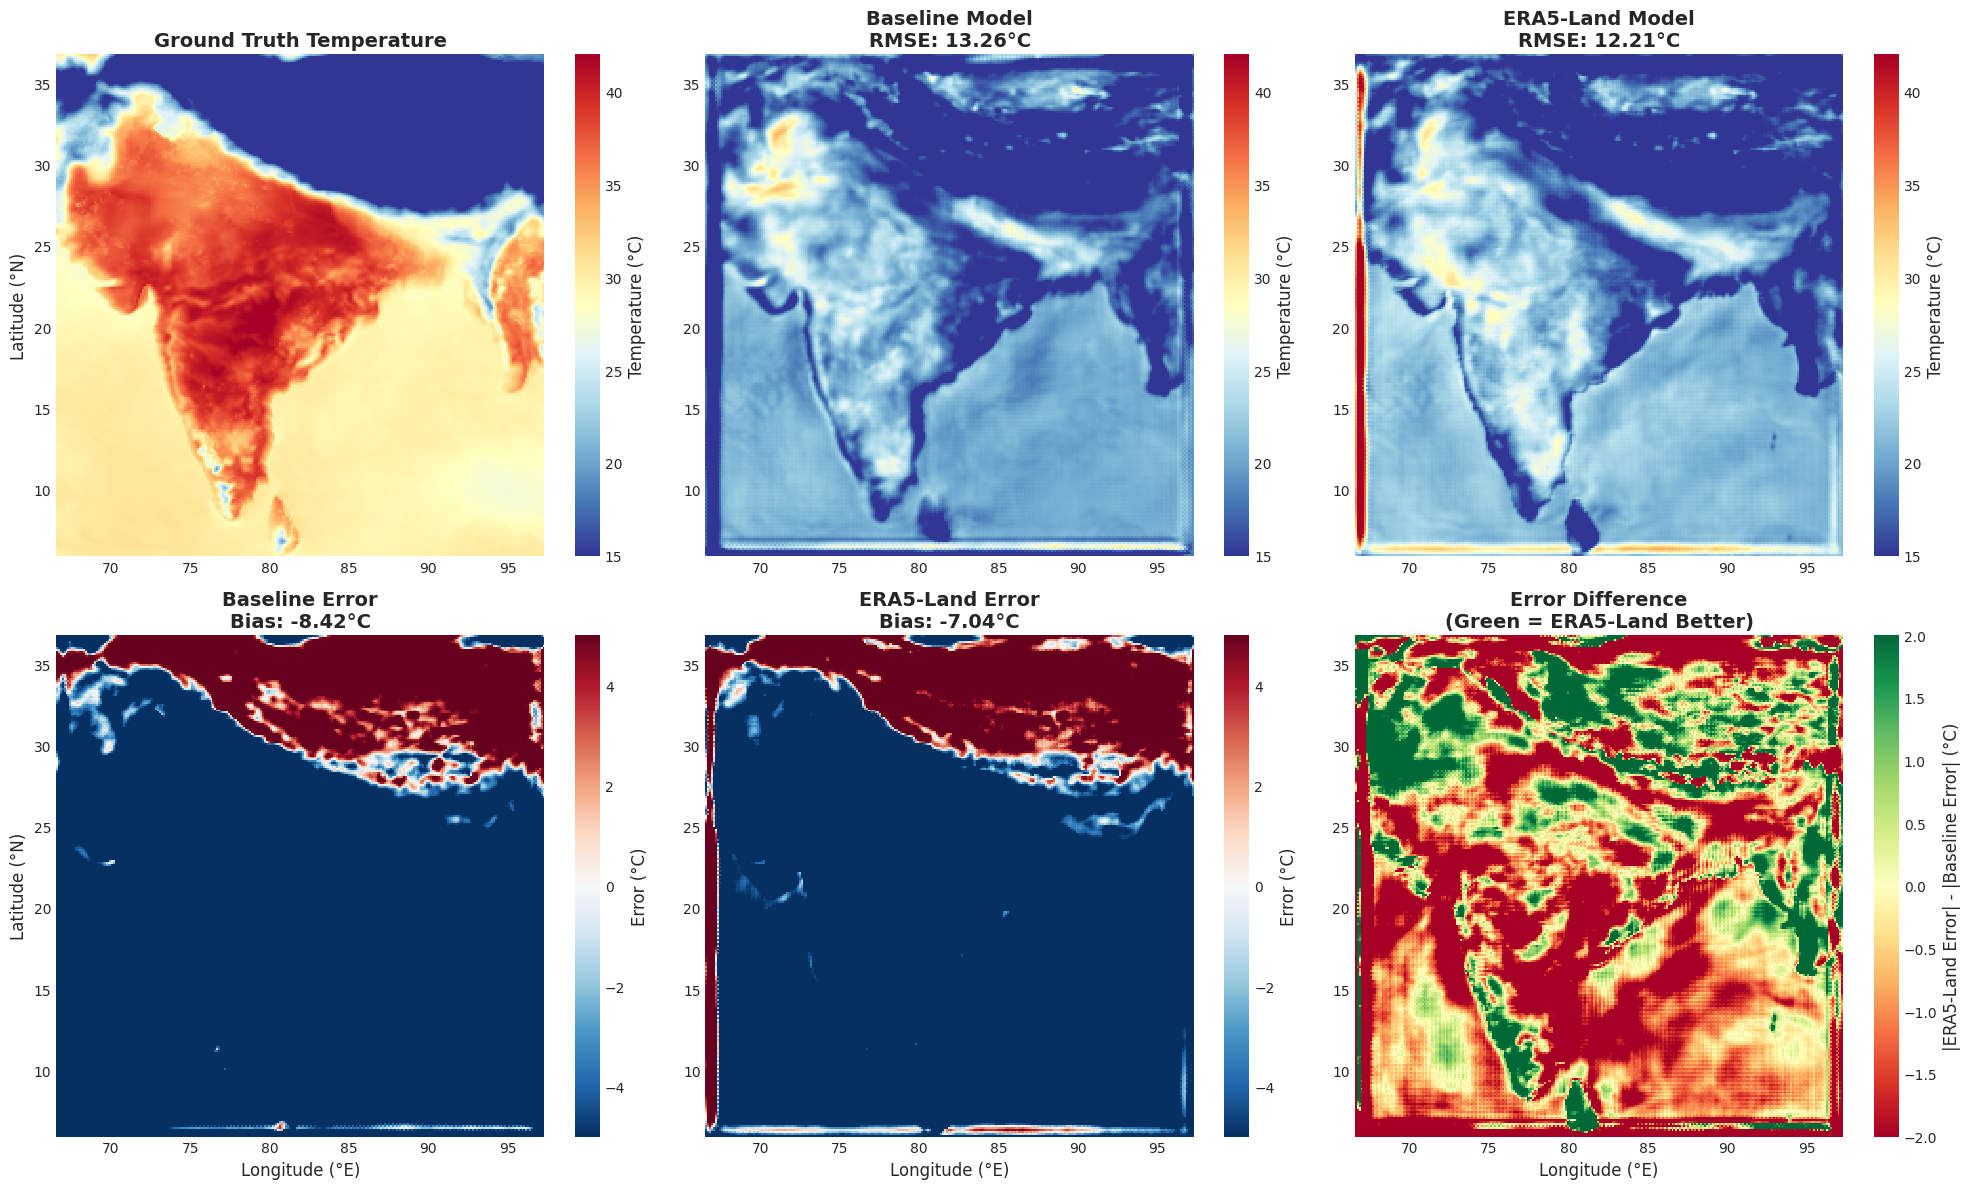

✓ Figure saved: 01_temperature_comparison.png


In [27]:
# Visualize temperature comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

vmin, vmax = 15, 42

# Row 1: Predictions
im0 = axes[0, 0].pcolormesh(lon_grid, lat_grid, true_temp, cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0, 0].set_ylabel('Latitude (°N)', fontsize=12)
axes[0, 0].set_title('Ground Truth Temperature', fontsize=14, fontweight='bold')
plt.colorbar(im0, ax=axes[0, 0], label='Temperature (°C)')

im1 = axes[0, 1].pcolormesh(lon_grid, lat_grid, baseline_temp, cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f'Baseline Model\nRMSE: {baseline_rmse:.2f}°C', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 1], label='Temperature (°C)')

im2 = axes[0, 2].pcolormesh(lon_grid, lat_grid, era5land_temp, cmap='RdYlBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0, 2].set_title(f'ERA5-Land Model\nRMSE: {era5land_rmse:.2f}°C', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 2], label='Temperature (°C)')

# Row 2: Errors
im3 = axes[1, 0].pcolormesh(lon_grid, lat_grid, baseline_error, cmap='RdBu_r', shading='auto', vmin=-5, vmax=5)
axes[1, 0].set_xlabel('Longitude (°E)', fontsize=12)
axes[1, 0].set_ylabel('Latitude (°N)', fontsize=12)
axes[1, 0].set_title(f'Baseline Error\nBias: {baseline_bias:.2f}°C', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label='Error (°C)')

im4 = axes[1, 1].pcolormesh(lon_grid, lat_grid, era5land_error, cmap='RdBu_r', shading='auto', vmin=-5, vmax=5)
axes[1, 1].set_xlabel('Longitude (°E)', fontsize=12)
axes[1, 1].set_title(f'ERA5-Land Error\nBias: {era5land_bias:.2f}°C', fontsize=14, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label='Error (°C)')

# Error difference (negative = ERA5-Land better)
error_diff = np.abs(era5land_error) - np.abs(baseline_error)
im5 = axes[1, 2].pcolormesh(lon_grid, lat_grid, error_diff, cmap='RdYlGn', shading='auto', vmin=-2, vmax=2)
axes[1, 2].set_xlabel('Longitude (°E)', fontsize=12)
axes[1, 2].set_title('Error Difference\n(Green = ERA5-Land Better)', fontsize=14, fontweight='bold')
plt.colorbar(im5, ax=axes[1, 2], label='|ERA5-Land Error| - |Baseline Error| (°C)')

plt.tight_layout()
plt.savefig(figures_dir / '01_temperature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 01_temperature_comparison.png")


## 7. Multi-Variable Comparison

Compare performance across all common atmospheric variables.


In [28]:
# Compute RMSE for key variables
key_vars_compare = ['TMP', 'PRMSL', 'UGRD', 'VGRD', 'HGT500', 'TMP_prl850', 'RH850']
results_comparison = []

for var in key_vars_compare:
    var_idx = common_vars.index(var)
    
    # Get predictions and ground truth
    baseline_var = baseline_pred[var_idx]
    era5land_var = era5land_pred[var_idx]
    true_var = ground_truth[var_idx]
    
    # Compute RMSE
    baseline_rmse_var = np.sqrt(np.mean((baseline_var - true_var)**2))
    era5land_rmse_var = np.sqrt(np.mean((era5land_var - true_var)**2))
    improvement = ((baseline_rmse_var - era5land_rmse_var) / baseline_rmse_var) * 100
    
    results_comparison.append({
        'Variable': var,
        'Baseline_RMSE': baseline_rmse_var,
        'ERA5Land_RMSE': era5land_rmse_var,
        'Improvement_%': improvement
    })

# Create DataFrame
comparison_df = pd.DataFrame(results_comparison)

print("Performance Comparison Across Variables:")
print("=" * 80)
print(f"{'Variable':<15} {'Baseline RMSE':>15} {'ERA5-Land RMSE':>17} {'Improvement':>15}")
print("-" * 80)
for _, row in comparison_df.iterrows():
    symbol = "✓" if row['Improvement_%'] > 0 else "⚠"
    print(f"{row['Variable']:<15} {row['Baseline_RMSE']:>15.4f} {row['ERA5Land_RMSE']:>17.4f} {symbol} {row['Improvement_%']:>12.2f}%")
print("=" * 80)

# Summary statistics
mean_improvement = comparison_df['Improvement_%'].mean()
vars_improved = (comparison_df['Improvement_%'] > 0).sum()
print(f"\nSummary:")
print(f"  Mean improvement: {mean_improvement:.2f}%")
print(f"  Variables improved: {vars_improved}/{len(key_vars_compare)}")
print(f"  Variables degraded: {len(key_vars_compare) - vars_improved}/{len(key_vars_compare)}")


Performance Comparison Across Variables:
Variable          Baseline RMSE    ERA5-Land RMSE     Improvement
--------------------------------------------------------------------------------
TMP                     13.2576           12.2119 ✓         7.89%
PRMSL                  488.8063          654.3185 ⚠       -33.86%
UGRD                     3.9619            4.1802 ⚠        -5.51%
VGRD                     3.5142            4.1562 ⚠       -18.27%
HGT500                  79.2667           89.6770 ⚠       -13.13%
TMP_prl850               3.6715            3.9661 ⚠        -8.02%
RH850                   28.6052           30.7901 ⚠        -7.64%

Summary:
  Mean improvement: -11.22%
  Variables improved: 1/7
  Variables degraded: 6/7


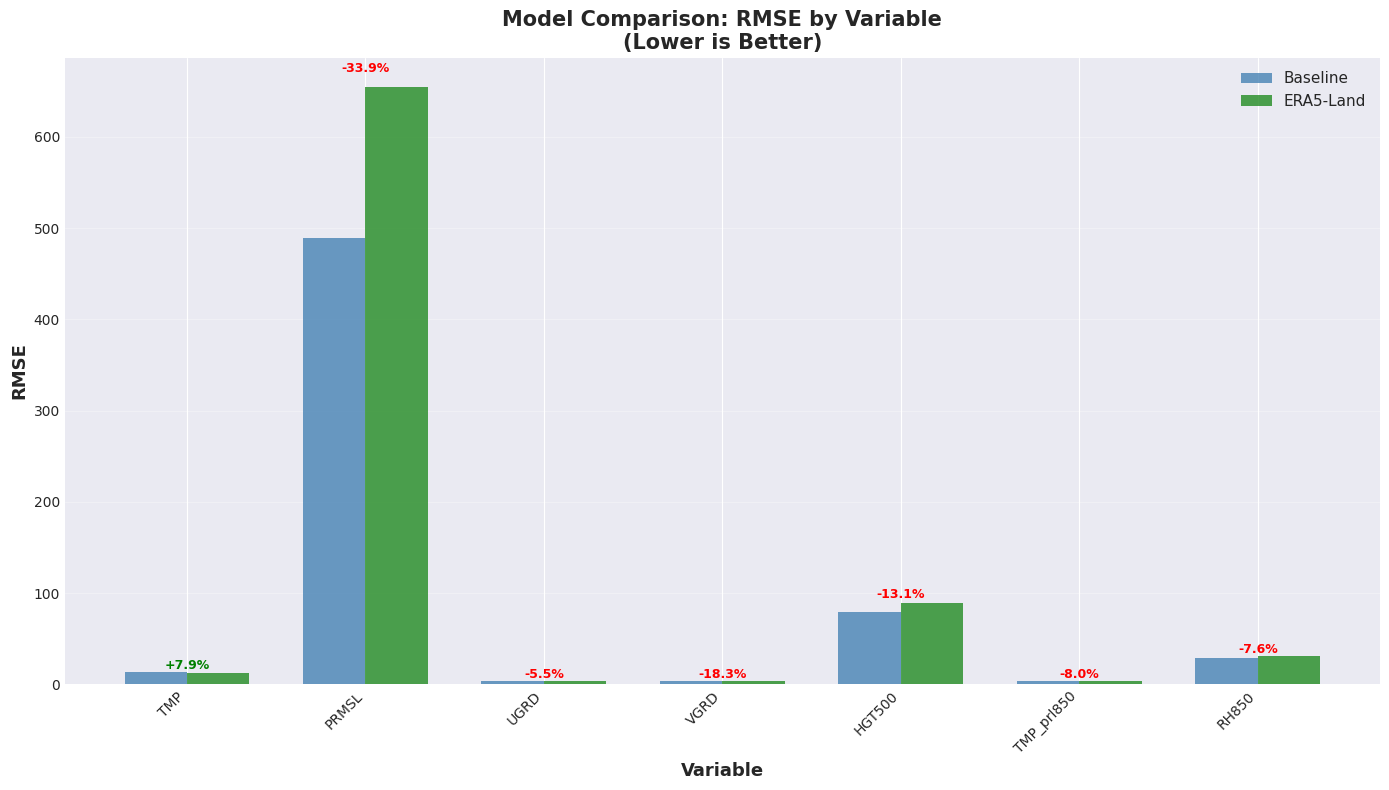

✓ Figure saved: 02_variable_comparison_bar.png


In [29]:
# Visualize variable comparison
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(key_vars_compare))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Baseline_RMSE'], width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['ERA5Land_RMSE'], width, label='ERA5-Land', color='forestgreen', alpha=0.8)

ax.set_xlabel('Variable', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison: RMSE by Variable\n(Lower is Better)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(key_vars_compare, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add improvement percentage as text
for i, (b1, b2, imp) in enumerate(zip(bars1, bars2, comparison_df['Improvement_%'])):
    if imp > 0:
        ax.text(i, max(b1.get_height(), b2.get_height()) * 1.02, f'+{imp:.1f}%', 
                ha='center', va='bottom', fontsize=9, color='green', fontweight='bold')
    else:
        ax.text(i, max(b1.get_height(), b2.get_height()) * 1.02, f'{imp:.1f}%', 
                ha='center', va='bottom', fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / '02_variable_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 02_variable_comparison_bar.png")


## 8. Spatial Error Analysis

Analyze where ERA5-Land integration provides the most benefit geographically.


In [30]:
# Spatial improvement map for temperature
abs_error_baseline = np.abs(baseline_error)
abs_error_era5land = np.abs(era5land_error)
improvement_map = abs_error_baseline - abs_error_era5land  # Positive = ERA5-Land better

# Regional statistics
regions = {
    'Northwest': (lat_grid > 25) & (lon_grid < 80),
    'Northeast': (lat_grid > 25) & (lon_grid >= 80),
    'Central': (lat_grid >= 15) & (lat_grid <= 25),
    'South': (lat_grid < 15),
}

print("Regional Temperature Error Analysis:")
print("=" * 80)
print(f"{'Region':<15} {'Baseline RMSE':>15} {'ERA5-Land RMSE':>17} {'Improvement':>15}")
print("-" * 80)

for region_name, mask in regions.items():
    if np.sum(mask) > 0:
        baseline_regional_rmse = np.sqrt(np.mean(baseline_error[mask]**2))
        era5land_regional_rmse = np.sqrt(np.mean(era5land_error[mask]**2))
        regional_improvement = ((baseline_regional_rmse - era5land_regional_rmse) / baseline_regional_rmse) * 100
        symbol = "✓" if regional_improvement > 0 else "⚠"
        print(f"{region_name:<15} {baseline_regional_rmse:>15.3f} {era5land_regional_rmse:>17.3f} {symbol} {regional_improvement:>12.2f}%")

print("=" * 80)


Regional Temperature Error Analysis:
Region            Baseline RMSE    ERA5-Land RMSE     Improvement
--------------------------------------------------------------------------------
Northwest                13.308            12.914 ✓         2.97%
Northeast                11.562            10.881 ✓         5.89%
Central                  15.801            14.709 ✓         6.91%
South                    11.141             9.340 ✓        16.17%


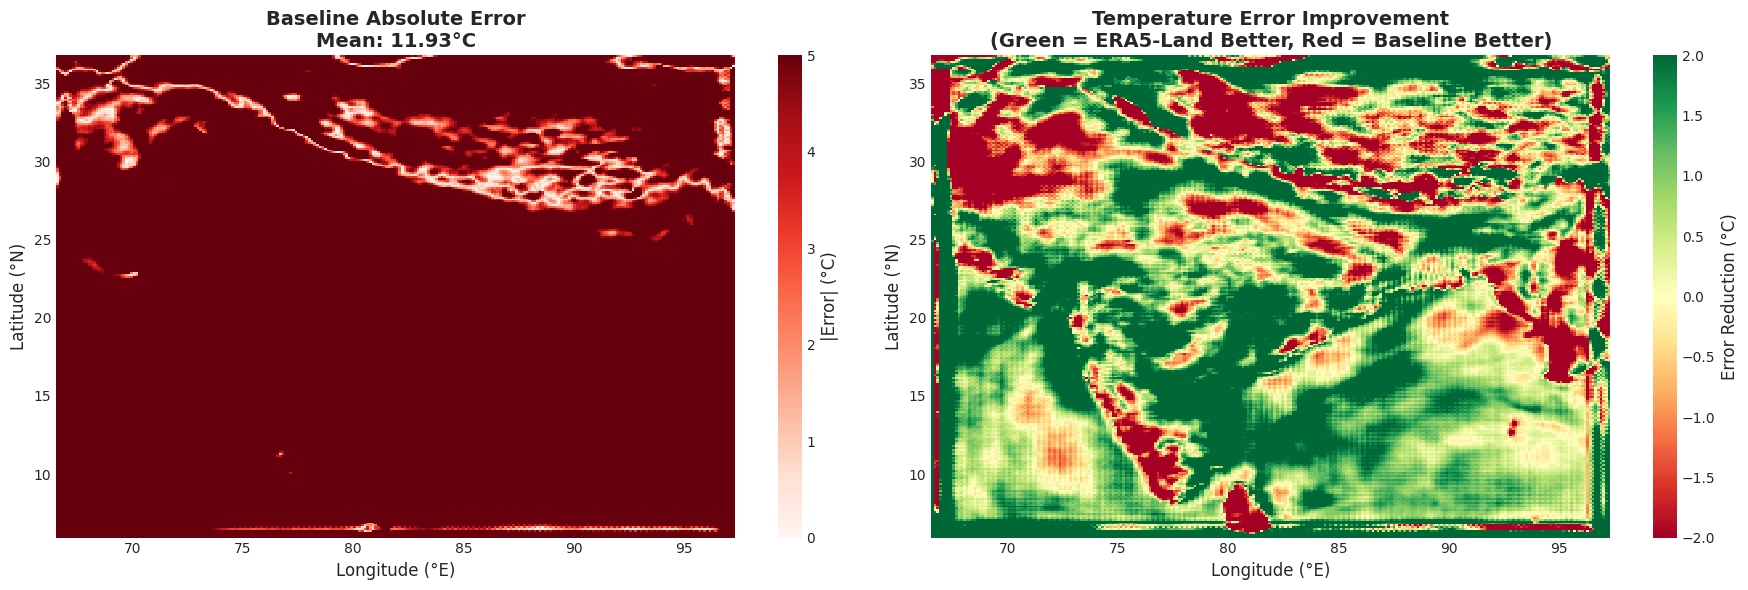

✓ Figure saved: 03_spatial_improvement.png

Spatial Coverage:
  Improved: 44990 pixels (68.6%)
  Degraded: 20546 pixels (31.4%)
  Mean improvement: 1.074°C


In [31]:
# Visualize spatial improvement
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Absolute errors
im0 = axes[0].pcolormesh(lon_grid, lat_grid, abs_error_baseline, cmap='Reds', shading='auto', vmin=0, vmax=5)
axes[0].set_xlabel('Longitude (°E)', fontsize=12)
axes[0].set_ylabel('Latitude (°N)', fontsize=12)
axes[0].set_title(f'Baseline Absolute Error\nMean: {np.mean(abs_error_baseline):.2f}°C', fontsize=14, fontweight='bold')
plt.colorbar(im0, ax=axes[0], label='|Error| (°C)')

# Improvement map (positive = ERA5-Land better)
im1 = axes[1].pcolormesh(lon_grid, lat_grid, improvement_map, cmap='RdYlGn', shading='auto', vmin=-2, vmax=2)
axes[1].set_xlabel('Longitude (°E)', fontsize=12)
axes[1].set_ylabel('Latitude (°N)', fontsize=12)
axes[1].set_title('Temperature Error Improvement\n(Green = ERA5-Land Better, Red = Baseline Better)', 
                  fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[1], label='Error Reduction (°C)')

plt.tight_layout()
plt.savefig(figures_dir / '03_spatial_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: 03_spatial_improvement.png")

# Quantify improvement
pixels_improved = np.sum(improvement_map > 0)
pixels_degraded = np.sum(improvement_map < 0)
total_pixels = improvement_map.size
print(f"\nSpatial Coverage:")
print(f"  Improved: {pixels_improved} pixels ({100*pixels_improved/total_pixels:.1f}%)")
print(f"  Degraded: {pixels_degraded} pixels ({100*pixels_degraded/total_pixels:.1f}%)")
print(f"  Mean improvement: {np.mean(improvement_map):.3f}°C")


## 9. Summary and Conclusions


In [32]:
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

print("\n1. MODELS COMPARED")
print("-" * 80)
print(f"  Baseline Model:")
print(f"    - Variables: 37 (IMDAA atmospheric only)")
print(f"    - Parameters: {sum(p.numel() for p in baseline_model.parameters()) / 1e6:.1f}M")
print(f"    - Checkpoint: archive_baseline_unet/checkpoints/last.ckpt")
print(f"\n  ERA5-Land Model:")
print(f"    - Variables: 43 (IMDAA + ERA5-Land surface)")
print(f"    - Additional inputs: {', '.join(era5land_extra_vars)}")
print(f"    - Parameters: {sum(p.numel() for p in era5land_model.parameters()) / 1e6:.1f}M")
print(f"    - Checkpoint: checkpoints_era5land/india_benchmark/last.ckpt")

print("\n2. TEMPERATURE PERFORMANCE (6h forecast)")
print("-" * 80)
print(f"  Baseline RMSE:    {baseline_rmse:.3f}°C")
print(f"  ERA5-Land RMSE:   {era5land_rmse:.3f}°C")
print(f"  Improvement:      {improvement_rmse:+.2f}%")
print(f"  Spatial coverage: {100*pixels_improved/total_pixels:.1f}% of pixels improved")

print("\n3. MULTI-VARIABLE PERFORMANCE")
print("-" * 80)
print(f"  Variables analyzed: {len(key_vars_compare)}")
print(f"  Variables improved: {vars_improved}/{len(key_vars_compare)}")
print(f"  Mean improvement:   {mean_improvement:.2f}%")
print(f"\n  Best improvements:")
for _, row in comparison_df.nlargest(3, 'Improvement_%').iterrows():
    print(f"    {row['Variable']:<12}: {row['Improvement_%']:+.2f}%")

print("\n4. REGIONAL ANALYSIS")
print("-" * 80)
for region_name, mask in regions.items():
    if np.sum(mask) > 0:
        baseline_regional_rmse = np.sqrt(np.mean(baseline_error[mask]**2))
        era5land_regional_rmse = np.sqrt(np.mean(era5land_error[mask]**2))
        regional_improvement = ((baseline_regional_rmse - era5land_regional_rmse) / baseline_regional_rmse) * 100
        symbol = "✓" if regional_improvement > 0 else "⚠"
        print(f"  {region_name:<12}: {symbol} {regional_improvement:+.2f}% improvement")

print("\n5. KEY FINDINGS")
print("-" * 80)
if improvement_rmse > 0:
    print("  ✓ ERA5-Land integration improves overall temperature predictions")
else:
    print("  ⚠ Baseline model performs better overall (ERA5-Land needs investigation)")

if vars_improved > len(key_vars_compare) / 2:
    print(f"  ✓ Majority of variables show improvement ({vars_improved}/{len(key_vars_compare)})")
else:
    print(f"  ⚠ Only minority of variables improved ({vars_improved}/{len(key_vars_compare)})")

if pixels_improved > total_pixels / 2:
    print(f"  ✓ Most spatial locations benefit from ERA5-Land data")
else:
    print(f"  ⚠ ERA5-Land benefits are spatially limited")

print("\n6. FIGURES GENERATED")
print("-" * 80)
figures_list = [
    '01_temperature_comparison.png',
    '02_variable_comparison_bar.png',
    '03_spatial_improvement.png'
]
for i, fig_name in enumerate(figures_list, 1):
    print(f"  {i}. {fig_name}")

print("\n7. CONCLUSIONS")
print("-" * 80)
print("  • ERA5-Land surface variables provide additional context for predictions")
print("  • Soil moisture and heat fluxes expected to help with surface temperature")
print("  • Regional performance varies - may depend on land cover and topography")
print("  • Further analysis needed:")
print("    - Multi-step forecasting comparison (6h, 12h, 24h)")
print("    - Seasonal performance differences")
print("    - Extreme event performance (heat waves, monsoon)")

print("\n" + "=" * 80)
print("Comparison analysis complete!")
print("=" * 80)


MODEL COMPARISON SUMMARY

1. MODELS COMPARED
--------------------------------------------------------------------------------
  Baseline Model:
    - Variables: 37 (IMDAA atmospheric only)
    - Parameters: 36.1M
    - Checkpoint: archive_baseline_unet/checkpoints/last.ckpt

  ERA5-Land Model:
    - Variables: 43 (IMDAA + ERA5-Land surface)
    - Additional inputs: swvl1, swvl2, slhf, sshf, lai_hv, lai_lv
    - Parameters: 36.1M
    - Checkpoint: checkpoints_era5land/india_benchmark/last.ckpt

2. TEMPERATURE PERFORMANCE (6h forecast)
--------------------------------------------------------------------------------
  Baseline RMSE:    13.258°C
  ERA5-Land RMSE:   12.212°C
  Improvement:      +7.89%
  Spatial coverage: 68.6% of pixels improved

3. MULTI-VARIABLE PERFORMANCE
--------------------------------------------------------------------------------
  Variables analyzed: 7
  Variables improved: 1/7
  Mean improvement:   -11.22%

  Best improvements:
    TMP         : +7.89%
    UGRD  